<h1> HW 2: Radar Imaging Part 3a</h1>


<h3> 3. 3D Imaging using 2D Antenna Array </h3>

This task includes two parts. Our goal is to implement radar signal processing for 3D imaging
using a 2D antenna array. You will implement two algorithms we taught in the class. 

<h5> 3.1 Algorithm 1 - Conventional Beam Forming </h5>

In this part, we will need to image the scene using Algorithm 1 we taught in class for a 2D antenna array. You will generate the 3D radar heatmap by estimating the
reflected signal power from every azimuth angles $\phi$ - elevation angles $\theta$ pair. Every azimuth
angle and elevation angle, along with the range will pinpoint a 3D voxel in the spherical
coordinates. To speed up the alogrithm, you can crop the range bins to be from 100 to 120 instead of using all 512 range bins.
The code for this task should be written in the functions *beamform_2d* defined below. We provide you
the code to load the radar data in the right format and to plot the 3D heatmap in this
file.

As results, you need to include the following in your report.
1. Generate a 3D heatmap for azimuth angle $\phi$ between 60 and 130 degrees with a resolution
of 1 degree, and elevation angle $\theta$ between 70 and 110 degrees with a resolution of 1 degrees. The
definition for $\phi$ and $\theta$ can be found in Fig. 1. Include the top view, side view, and
front view projections of the 3D heatmap in the spherical coordinates, as well as a
3D point cloud by setting a threshold on the heatmap and selecting the points with a
reflection power above this threshold. Examples of this plotting code is shown at the bottom of the file.

2. Generate the above 3D heatmaps and point clouds for all data provided. 

Write your algorithm below.

In [ ]:
################# Change the values based on how much of the azimuth angles you want to see and the resolution ##################
# Define field of view in degrees that you want to process in theta, phi and range bins
def beamform_2d(beat_freq_data, phi_s, phi_e, phi_res, theta_s, theta_e, theta_res, x_locs, z_locs, r_idxs, radar_params):
    """
    Performs 2D beamforming along the azimuth (horizontal) dimension, this results in a bird eye view image.
    - beat_freq_data: beat data AKA the range FFT (size: num_x_stps * num_z_stps * num TX * num RX, num ADC samples)
    - phi_s: first azimuth angle that you want to start computing 
    - phi_e: last azimuth angle that you want to compute 
    - phi_res: resolution of the azimuth angles you want to compute
    - theta_s: first elevation angle that you want to start computing 
    - theta_e: last elevation angle that you want to compute 
    - theta_res: resolution of the elevation angles you want to compute
    - x_locs: x coordinate of antenna locations
    - z_locs: z coordinate of antenna locations
    - r_idx: range bins to calculate 
    - radar_parms: radar_params if needed 

    Returns:
    - sph_pwr: beamformed result (size: n_phi, n_theta, n_range)
    - phi: array of azimuth angles 
    - theta: array of elevation angles 
    """
    lam = radar_params['lm']
    numSamples = radar_params['adc_samples']

    phiRange = np.arange(phi_s, phi_e + phi_res, phi_res)
    thetaRange = np.arange(theta_s, theta_e + theta_res, theta_res)

    numPhi = len(phiRange)
    numTheta = len(thetaRange)

    # Crop binms
    rangeBinStart = 100
    rangeBinEnd = 140
    numRangeBins = rangeBinEnd - rangeBinStart # clean up to mach r_idxs

    sph_pwr = np.zeros((numPhi, numTheta, numRangeBins))

    print(f"Xlocs shape: {x_locs.shape}, Zlocs shape: {z_locs.shape}, beat_freq_data shape: {beat_freq_data.shape}")

    xVirt = x_locs
    zVirt = z_locs

    # 1. Mix RX and TX, crop num inputs
    mixedSignal = beat_freq_data
    
    # 3. Compute range fft
    rangeFFT = np.fft.fft(mixedSignal, axis=-1)[:, r_idxs]

    for i, phi in enumerate(phiRange):

        # 2. Multiply the resulting signal on each antenna with exp(j*phi) and sum signals
        phiRads = np.deg2rad(phi)

        for j, theta in enumerate(thetaRange):
            thetaRads = np.deg2rad(theta)

            xPhase = (np.sin(thetaRads) * np.cos(phiRads))
            zPhase = (np.cos(thetaRads))

            xPart = xVirt * xPhase
            zPart = zVirt * zPhase
            phase = xPart + zPart
            
            steeringVector = np.exp(1j * 2*np.pi/lam * (phase))
            steeringVector = steeringVector.reshape(-1,1)
            
            beamformedSignal = np.sum(steeringVector * rangeFFT, axis=0)
            
            sph_pwr[i, j, :] = np.abs(beamformedSignal)**2 
            

            # 4. repeat in every direction
    return sph_pwr, np.deg2rad(phiRange), np.deg2rad(thetaRange)

In [239]:

import numpy as np
import matplotlib.pyplot as plt
import os
import scipy
import scipy.io as sio
import time
#import open3d as o3d
import utils 

Load data.

In [263]:
# Put the *path* to the project folder
data_path = r"D:/GitHub/COM-304/COM-304-Radars/homework/data/data_001_.mat"

# loading data that is given
"""
    raw_data: is the raw radar data (after mixing) of size (num_x_stp x num_rx, num_z_stp, adc_samples)
    radar_params: is a dictionary with radar and position parameters: 'sample_rate', 'num_samples', 'slope', 'lm'(lambda), 'num_x_stp', 'num_z_stp', 'num_tx', 'num_rx', 'adc_samples' 
"""
radar_params, raw_data = utils.load_raw_data(data_path)

Defining antenna positions. 

In [264]:
x_ant_pos, z_pos, x_ant = utils.get_ant_pos_2d(radar_params['num_x_stp'], radar_params['num_z_stp'], radar_params['num_rx']) # this returns x position of rx, z positions of rx and tx, and x position of tx

Process raw data for BF algorthim (use all samples now).

In [265]:
# reshape raw_data and process beat frequency
numX = radar_params['num_x_stp']
numZ = radar_params['num_z_stp']
numSamples = radar_params['adc_samples']
print(raw_data.shape)

beat_freq = raw_data.reshape(numX * numZ, numSamples)

(320, 369, 512)


Define the angles and range bins to run, and run the BF algo.

In [269]:
# define the azimuth angles (horizontal FOV) that we want to look at 
r_idxs = np.arange(100, 140, 1) # TODO: Change to distance rather than range bins 
phi_s, phi_e = 60, 130 
phi_res = 2
theta_s, theta_e = 70,110 
theta_res = 2
x_locs = x_ant_pos #+ x_ant
z_locs = z_pos

# Run your algorithm here
# input arguments that you choose
bf_output1, phi, theta= beamform_2d(beat_freq, phi_s, phi_e, phi_res, theta_s, theta_e, theta_res, x_locs, z_locs, r_idxs, radar_params)

Xlocs shape: (320, 1), Zlocs shape: (1, 369), beat_freq_data shape: (118080, 512)
rangeFFT signal shape: (118080, 40)
sph_pwr shape: (36, 21, 40), phiRange shape: (36,), thetaRange shape: (21,)


Here you should plot the outputs from beamforming.


to_plot shape: (21, 40), theta shape: (21,), r_idxs shape: (40,)
1.0


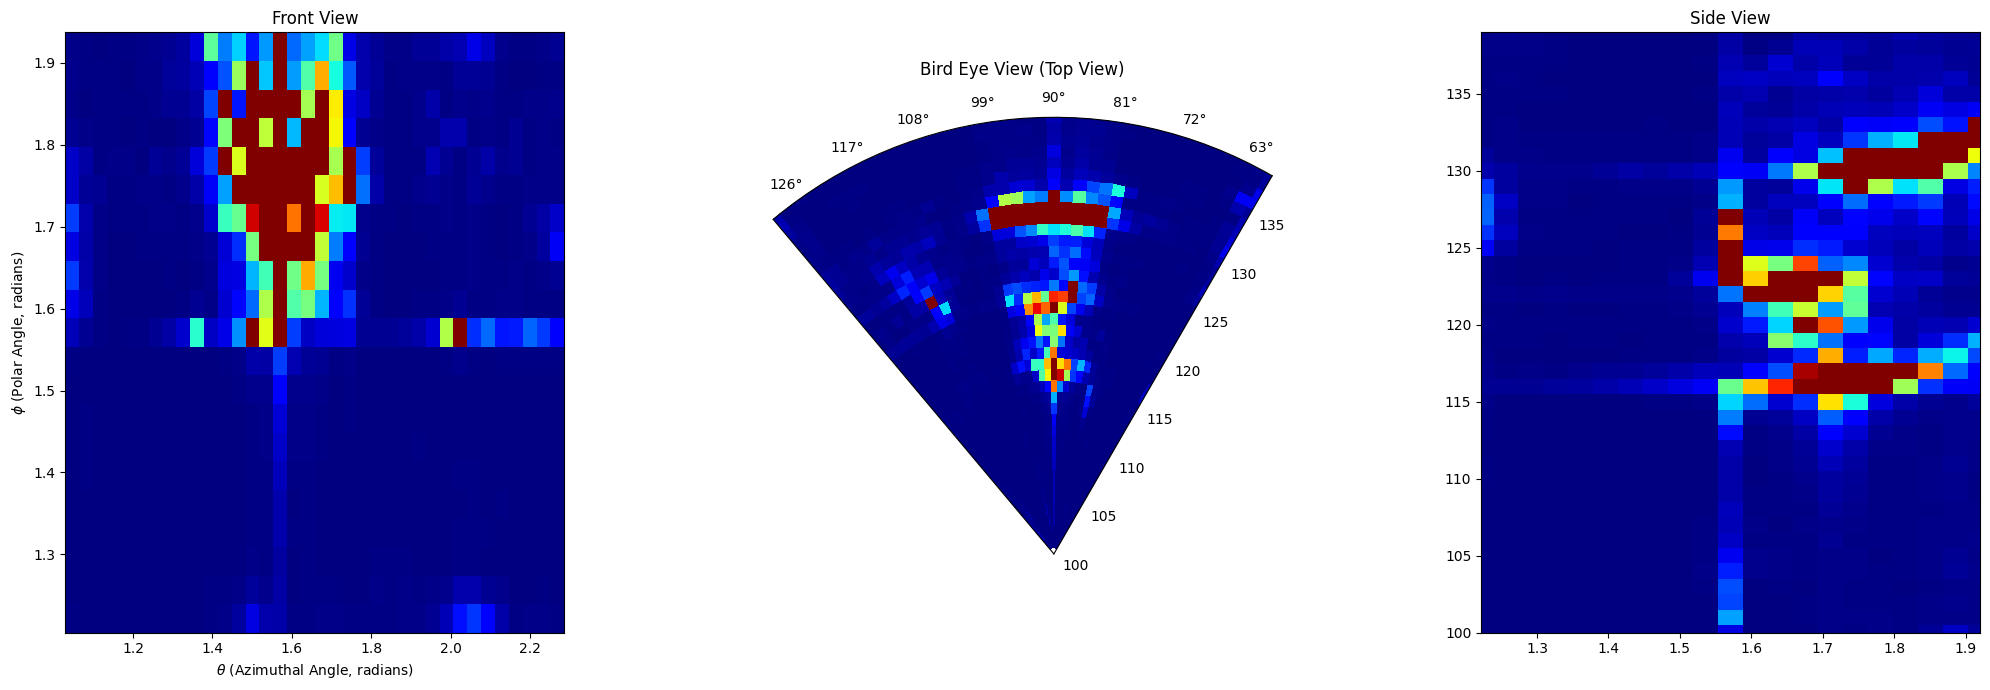

In [ ]:
# Plot the output from 2D Beamforming (You can change this as you see fit)
fig = plt.figure(figsize=(20, 7))

to_plot = np.sum(abs(bf_output1),axis=-1)
to_plot = to_plot/np.max(np.reshape(to_plot,(1,-1))) 
to_plot = to_plot#**2
print()
ax0 = fig.add_subplot(131)
utils.plot_2d_polar_heatmap(ax0, to_plot, phi, theta, vmin=0, vmax=0.07)
ax0.title.set_text('Front View')

to_plot = np.sum(abs(bf_output1),axis=1)
to_plot = to_plot/np.max(np.reshape(to_plot,(1,-1))) 
to_plot = to_plot#**2
ax1 = fig.add_subplot(132,projection = 'polar')
utils.plot_2d_heatmap(ax1, to_plot, phi, r_idxs, vmin=0, vmax=0.07)
ax1.title.set_text('Bird Eye View (Top View)')

to_plot = np.sum(abs(bf_output1),axis=0)
to_plot = to_plot/np.max(np.reshape(to_plot,(1,-1))) 
to_plot = to_plot#**2
ax2 = fig.add_subplot(133)
utils.plot_2d_heatmap(ax2, to_plot, theta, r_idxs, vmin=0, vmax=0.07)
ax2.title.set_text('Side View')
plt.tight_layout()
plt.show()

<h1> HW 2: Radar Imaging Part 3b</h1>


<h5> 3.b Algorithm 3 - Matched Filter </h5>

In this part, we will need to image the scene using Algorithm 3 we taught in class for a 2D antenna array. You will generate the 3D radar heatmap by estimating
the reflected signal power from every voxel in the 3D cartesian coordinates (x,y,z).
The code for this task should be written in the function matched_filter_2d. We provide you
the code to load the radar data in the right format and to plot the heatmap in this
file. Though the MF output can be 3D, because of compute time, we ask that you just show a single depth slice of the scene making the output 2D.

As results, you need to include the following in your report: 
1. Generate the heatmap for all 3 scenes given
in the cartesian coordinates. The space of interest is indicated in Data Details in the google drive. The spatial resolution
should be 0.01 for x and z. Plot the front view.

2. Compare the heatmaps with the corresponding one from Task 3a, and comment on
the differences.

Notes: 
- Running matched filter code in Python can be slow. 
- And remember to check parameter clim to get reasonable heatmaps. 


Implement your matched filter algortihm below. If you would like to speed up processing time you can try to optimize code --> (eg. Numba, multiprocessing,), additionlly for debugging we recommend processing lower resolution.

Additionally, you may move away from a Jupyter Notebook for this task only if you find that optmizing the code requires this. However, please attach the plots in a PDF in addition to plotting the output in your code if you follow this path.

In [3]:
######## 2D Imaging in Cartesian #############
def matched_filter_2d(raw_data_2d, x_grid, y_grid, z_grid, x_radar_tx, x_radar_rx, z_radar_tx, z_radar_rx):
    """
    Performs 2D matched filter on the raw data.
    - raw_data_2d: raw data  
    - x_grid: x axis values (azimuth)
    - y_grid: y axis values (range)
    - z_grid: z axis values (elevation)
    - x_radar_tx: transmitter positions (x) 
    - x_radar_rx: receiver positions (x)
    - z_radar_tx: transmitter positions (z)
    - z_radar_rx: receiver positions (z)
    
    Returns:
    - MF_output: matched filter output (size: len(x_grid) x len(y_grid)  x len(z_grid) aka azimuth, depth, elevation)
    """

    fs = radar_params['sample_rate']
    slope = radar_params['slope']
    lam = radar_params['lm']
    c = 3e8
    f0 = c/lam
    time = np.arange(raw_data_2d.shape[-1])/fs
 
    # 1) Descritize space into 𝐿×𝐿×𝐿 grid. 
    MF_output = np.zeros((len(x_grid), len(y_grid), len(z_grid)))

    mixedSignal = raw_data_2d

    print(f"X grid length: {len(x_grid)}, Y grid length: {len(y_grid)}, Z grid length: {len(z_grid)}")

    # 2) For each point in space compute the received signal using the equation.
    for ix, x in enumerate(x_grid):
        print(f"Starting iteration [{ix}/{len(x_grid)}] for matched filter computation...")
        x_comp_tx = x - x_radar_tx
        x_comp_rx = x - x_radar_rx
        
        for iy, y in enumerate(y_grid):
            for iz, z in enumerate(z_grid):
                
                voxel_sum = 0

                dist_tx = np.sqrt((x_comp_tx)**2 + y**2 + ((z - z_radar_tx)**2)) # tx needed?
                dist_rx = np.sqrt((x_comp_rx)**2 + y**2 + ((z - z_radar_rx)**2)) 
                dist = dist_rx + dist_tx

                constant = (slope * time/c + f0)

                exponent = np.exp(-2j*np.pi * dist[:,:,None] * constant[None, :])

                voxel_sum = np.einsum('mkt, mkt ->', mixedSignal, exponent)
                MF_output[ix, iy, iz] = np.abs(voxel_sum)**2

    return MF_output

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import os
import scipy
import scipy.io as sio
import time
#import open3d as o3d
#import helpers 
import utils

Load data.

In [5]:
# Put the *path* to the project folder
data_path = r"D:/GitHub/COM-304/COM-304-Radars/homework/data/data_003_.mat"

# loading data that is given
"""
    raw_data: is the raw radar data (after mixing) of size (num_x_stp x num_rx, num_z_stp, adc_samples)
    radar_params: is a dictionary with radar and position parameters: 'sample_rate', 'num_samples', 'slope', 'lm'(lambda), 'num_x_stp', 'num_z_stp', 'num_tx', 'num_rx', 'adc_samples' 
"""
radar_params, raw_data = utils.load_raw_data(data_path)

Defining antenna positions.

In [6]:
x_ant_pos, z_ant_pos, x_ant = utils.get_ant_pos_2d(radar_params['num_x_stp'], radar_params['num_z_stp'], radar_params['num_rx']) # this returns x position of rx, z positions of rx and tx, and x position of tx

Process raw data for MF algorthim (use all samples now).

In [7]:
# reshape raw_data for MF function
numX = radar_params['num_x_stp']
numZ = radar_params['num_z_stp']
numSamples = radar_params['adc_samples']

raw_data_2d = raw_data#.reshape(numX, numZ, numSamples)


Define the x,y,z voxels to calculate and the radars transmitter and receiver positions in x and z. Then run your algorithm. We recommend processing at lower resolution (eg. 0.05) or smaller portions of space for debugging.

In [21]:
# fill in the missing values below, from data details
res = 0.05
min_x, max_x = -0.12, 0.46
min_y, max_y = 4.2, 4.4
min_z, max_z = -0.40, 0.25

x_grid = np.arange(min_x, max_x, step=res)
y_grid = np.arange(min_y, max_y, step=res)
z_grid = np.arange(min_z, max_z, step=res)

# transmitters x position is one every lambda (repeat by four to match size of x_radar_rx) and shift by the physical offset on the board
lam = radar_params['lm']
offset = 0.005 + 3*lam/2

x_radar_tx = (np.kron(x_ant, np.ones(4,)).reshape(-1,1)) + offset
x_radar_rx = x_ant_pos
z_radar_tx = z_ant_pos  
z_radar_rx = z_ant_pos

# Run matched filter algorithm
MF_output = matched_filter_2d(raw_data_2d, x_grid, y_grid, z_grid, x_radar_tx, x_radar_rx, z_radar_tx, z_radar_rx)


""" 
--------------------------------------------
PLEASE SEE NOTES AT END OF NOTEBOOK FILE
--------------------------------------------
"""

X grid length: 12, Y grid length: 5, Z grid length: 13
Starting iteration [0/12] for matched filter computation...


KeyboardInterrupt: 

Plot your outputs below.

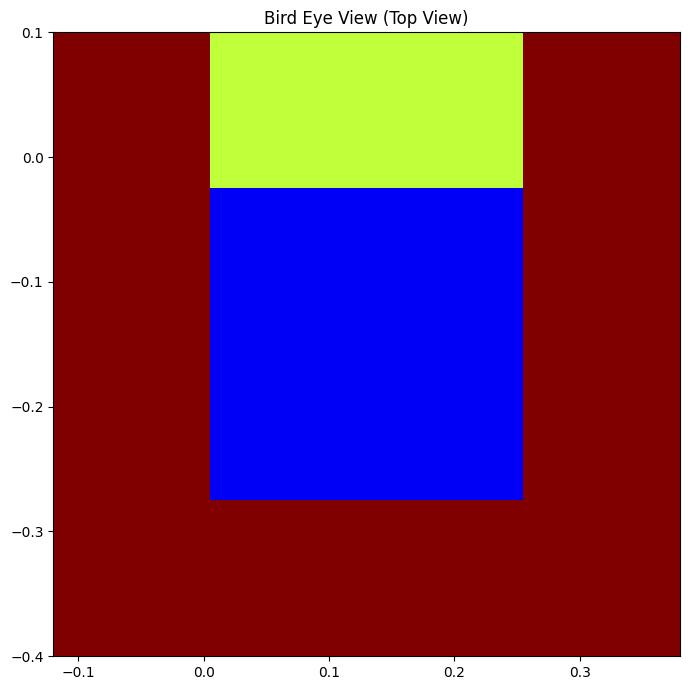

In [188]:
# Plot the output from MF (You can change this as you see fit (this will just plot the front of the object as we are not processing the entire heatmap)
fig = plt.figure(figsize=(7, 7))

to_plot = np.sum(abs(MF_output), axis=1)
to_plot = to_plot/np.max(np.reshape(to_plot,(1,-1))) 
to_plot = to_plot#**2

ax0 = fig.add_subplot(111)
utils.plot_2d_heatmap(ax0, to_plot, x_grid, z_grid, vmin=0, vmax=0.07)
ax0.title.set_text('Bird Eye View (Top View)')

plt.tight_layout()
plt.show()


# OUTPUT for all 3 scenes

In [13]:
# Put the *path* to the project folder
data_path1 = r"D:/GitHub/COM-304/COM-304-Radars/homework/data/data_001_.mat"
radar_params1, raw_data1 = utils.load_raw_data(data_path1)

data_path2 = r"D:/GitHub/COM-304/COM-304-Radars/homework/data/data_003_.mat"
radar_params2, raw_data2 = utils.load_raw_data(data_path2)

data_path3 = r"D:/GitHub/COM-304/COM-304-Radars/homework/data/data_010_.mat"
radar_params3, raw_data3 = utils.load_raw_data(data_path3)

In [14]:
def generateMFPlot(output, gridx, gridz):
    # Plot the output from MF (You can change this as you see fit (this will just plot the front of the object as we are not processing the entire heatmap)
    fig = plt.figure(figsize=(7, 7))

    to_plot = np.sum(abs(output), axis=1)
    to_plot = to_plot/np.max(np.reshape(to_plot,(1,-1))) 
    to_plot = to_plot#**2

    ax0 = fig.add_subplot(111)
    utils.plot_2d_heatmap(ax0, to_plot, gridx, gridz, vmin=0, vmax=0.07)
    ax0.title.set_text('Bird Eye View (Top View)')

    plt.tight_layout()
    plt.show()

In [17]:
# New Constants ------------------------------------------
res = 0.3

# transmitters x position is one every lambda (repeat by four to match size of x_radar_rx) and shift by the physical offset on the board
lam = radar_params['lm']
offset = 0.005 + 3*lam/2

x_radar_tx = (np.kron(x_ant, np.ones(4,)).reshape(-1,1)) #+ offset
x_radar_rx = x_ant_pos + offset
z_radar_tx = z_ant_pos  
z_radar_rx = z_ant_pos

X grid length: 3, Y grid length: 2, Z grid length: 2
Starting iteration [0/3] for matched filter computation...
Starting iteration [1/3] for matched filter computation...
Starting iteration [2/3] for matched filter computation...
------- Plot for data 001 ---------


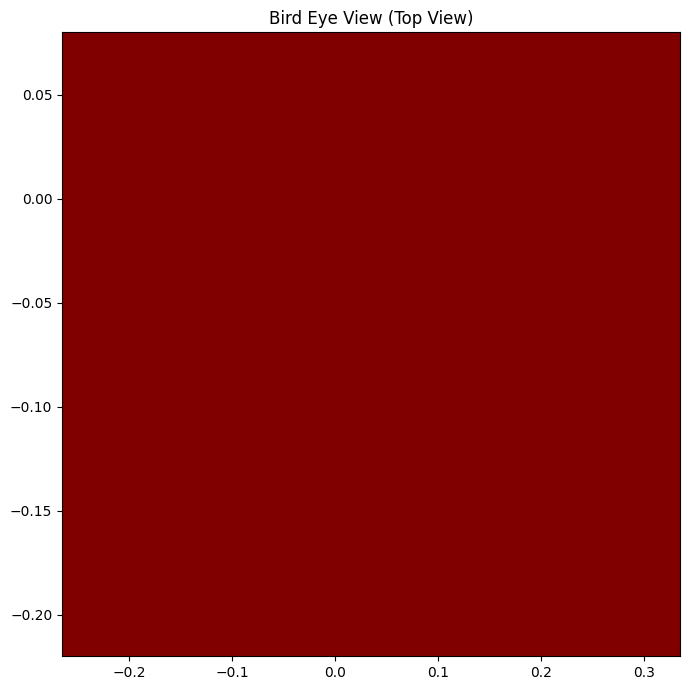

In [18]:
# Scene 1 - Data 001 ------------------------------------
min_x1, max_x1 = -0.265, 0.465
min_y1, max_y1 = 4.725, 5.075
min_z1, max_z1 = -0.22, 0.175

x1_grid = np.arange(min_x1, max_x1, step=res)
y1_grid = np.arange(min_y1, max_y1, step=res)
z1_grid = np.arange(min_z1, max_z1, step=res)

MF_output1 = matched_filter_2d(raw_data1, x1_grid, y1_grid, z1_grid, x_radar_tx, x_radar_rx, z_radar_tx, z_radar_rx)
print("------- Plot for data 001 ---------")
generateMFPlot(MF_output1, x1_grid, z1_grid)

X grid length: 2, Y grid length: 1, Z grid length: 3
Starting iteration [0/2] for matched filter computation...
Starting iteration [1/2] for matched filter computation...
------- Plot for data 003 --------


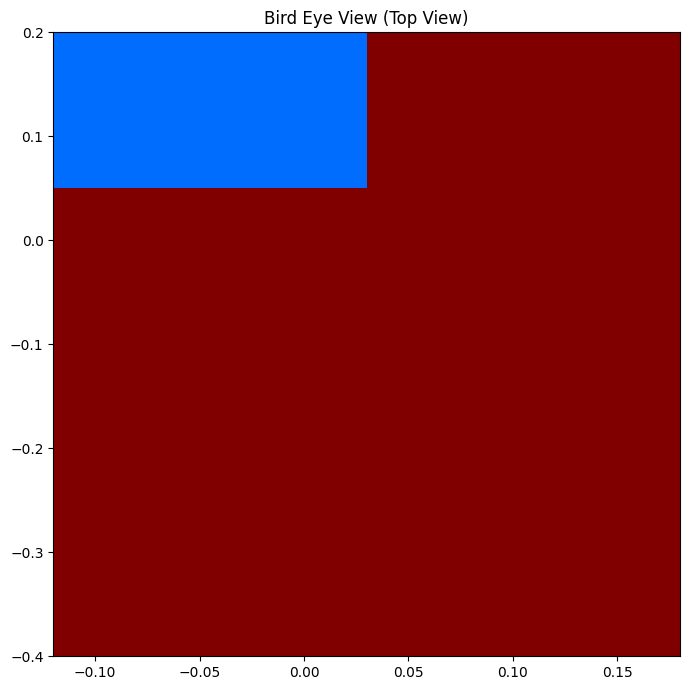

In [19]:
# Scene 2 - Data 003 -----------------------------------
min_x2, max_x2 = -0.12, 0.46
min_y2, max_y2 = 4.2, 4.4
min_z2, max_z2 = -0.40, 0.25

x2_grid = np.arange(min_x2, max_x2, step=res)
y2_grid = np.arange(min_y2, max_y2, step=res)
z2_grid = np.arange(min_z2, max_z2, step=res)

MF_output2 = matched_filter_2d(raw_data2, x2_grid, y2_grid, z2_grid, x_radar_tx, x_radar_rx, z_radar_tx, z_radar_rx)
print("------- Plot for data 003 --------")
generateMFPlot(MF_output2, x2_grid, z2_grid)

X grid length: 2, Y grid length: 2, Z grid length: 2
Starting iteration [0/2] for matched filter computation...
Starting iteration [1/2] for matched filter computation...
------- Plot for data 010 --------


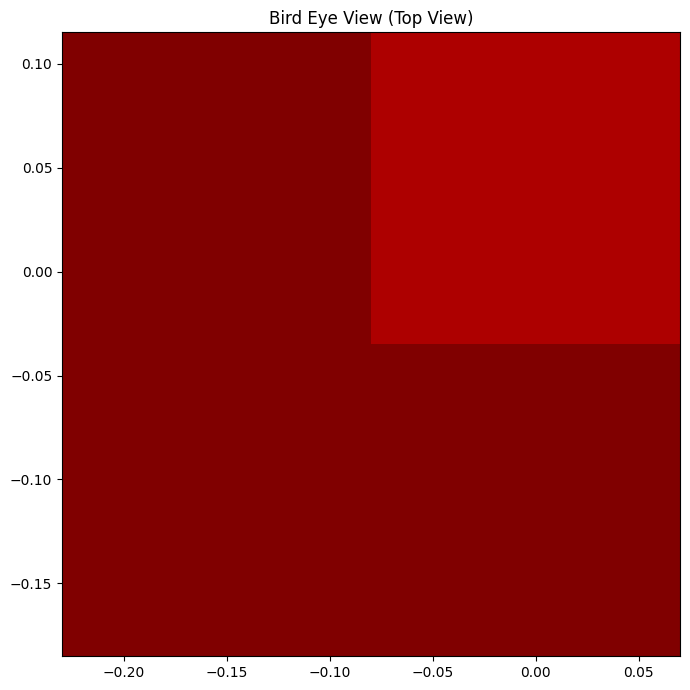

In [20]:
# SCENE 3 - Data 010 ---------------------------------
min_x3, max_x3 = -0.23, 0.22
min_y3, max_y3 = 4.35, 4.65
min_z3, max_z3 = -0.185, 0.24

x3_grid = np.arange(min_x3, max_x3, step=res)
y3_grid = np.arange(min_y3, max_y3, step=res)
z3_grid = np.arange(min_z3, max_z3, step=res)

MF_output3 = matched_filter_2d(raw_data3, x3_grid, y3_grid, z3_grid, x_radar_tx, x_radar_rx, z_radar_tx, z_radar_rx)
print("------- Plot for data 010 --------")
generateMFPlot(MF_output3, x3_grid, z3_grid)

## Comments on the differences between the heatmaps from Task 3a and Task 3b.
*General Comment:* it was expected that the matched filter output would be more focused and have higher resolution than the beamforming output, as the matched filter is designed to maximize the signal-to-noise ratio for a given target. However, the actual results may vary based on the specific implementation and parameters used in both algorithms. The ability to test these differences was limited by the severe runtime of the matched filter algorithm on my laptop, which made it difficult to process the data at higher resolutions in a reasonable time frame. The code was runnig for 215 minutes at a 0.01 resolution before I had to stop it as no end was in sight (see picture at bottom) and it's taking over 10 minutes per single iteration through the x-grid (outer loop) making it really hard to verify if output plots are as we would expect.

### Data 001
- hard to derive any conclusions. Appears to follow part a roughly for similar step sizes
### Data 003
- we can observe that the inital plot directly below the matched flter function is close to that of part a, and so it can be assumed that the function is following the correct implementation.
### Data 010
- hard to derive any conclusions. Appears to follow similar form as part a but with more noise and less resolution as expected.

## Notes For Marker
The runtime was so severe on my laptop (i'm having real issues as you may have seen in the tutorial sessions) and so it was very difficult to test out my functions on higher resolutions in decent time. See some evidence below:


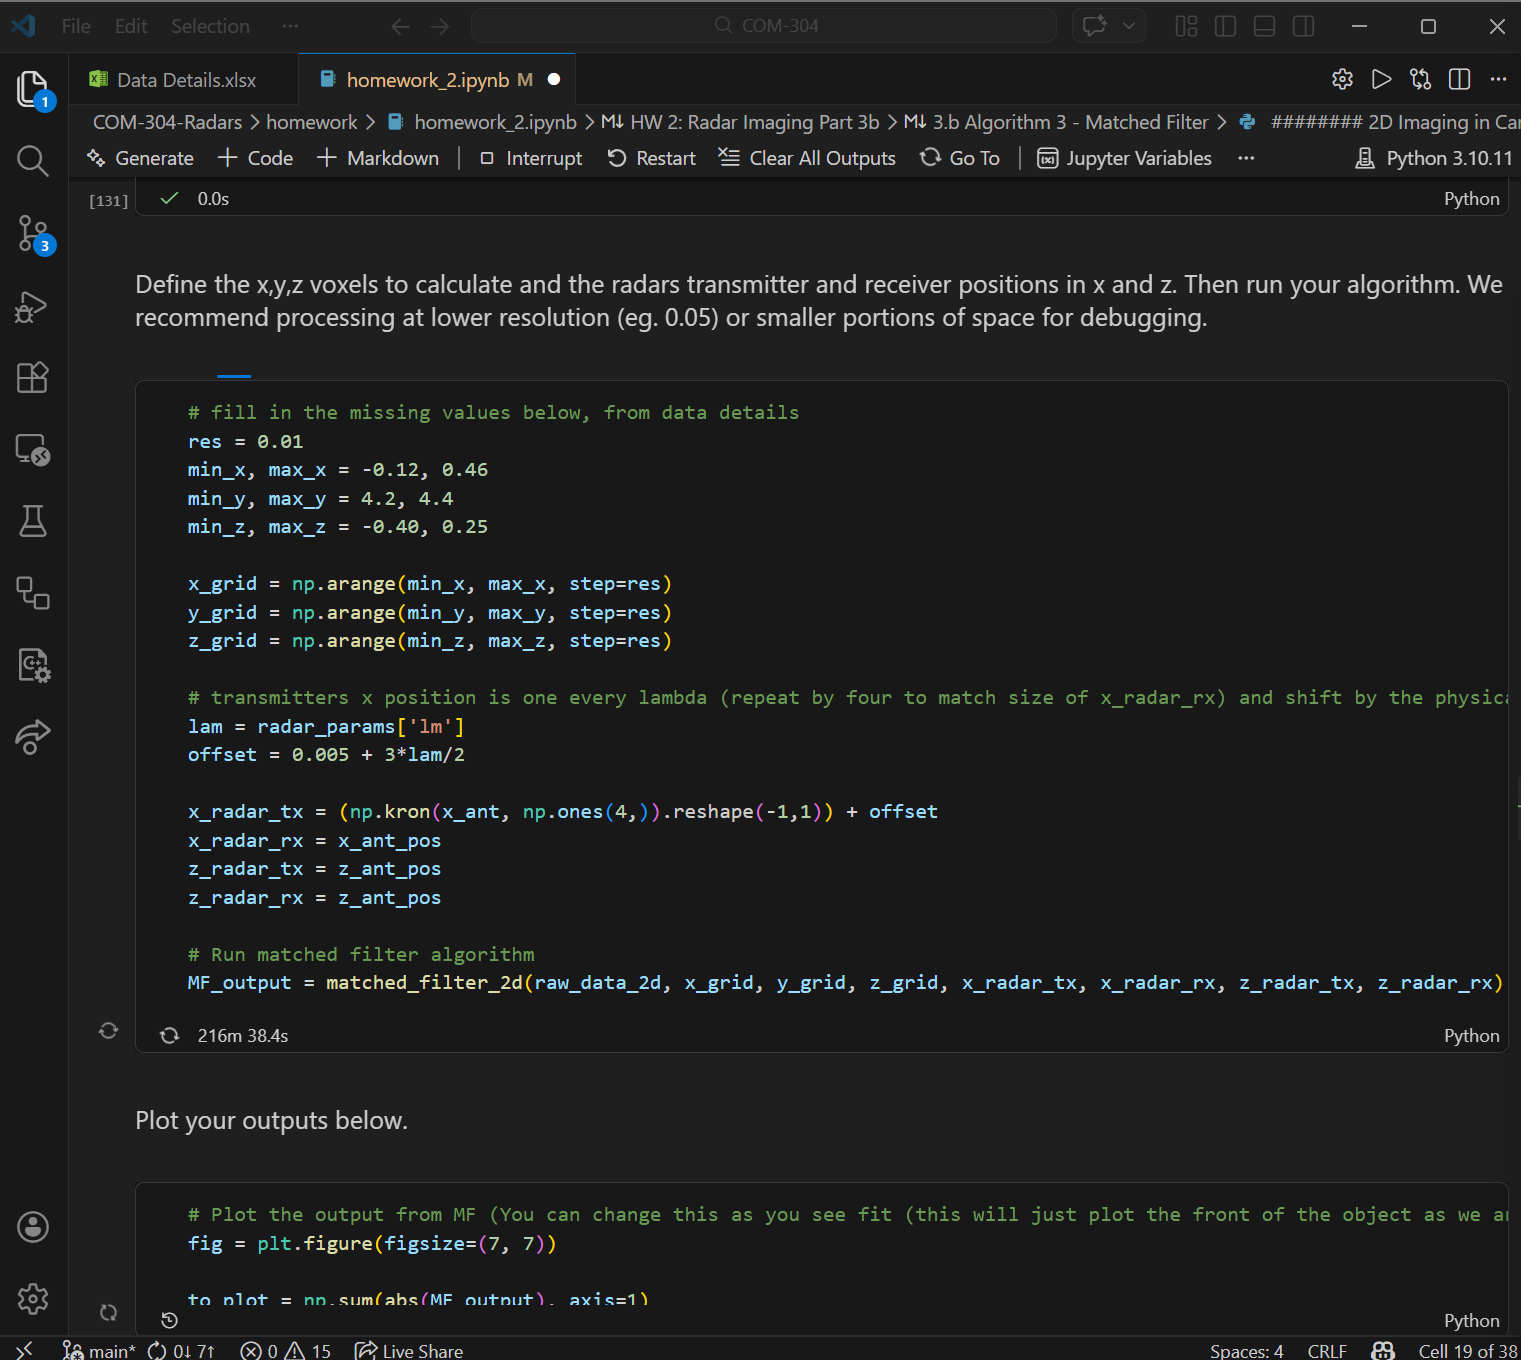


Also, 10 minutes per iteration at a resolution size of 0.05
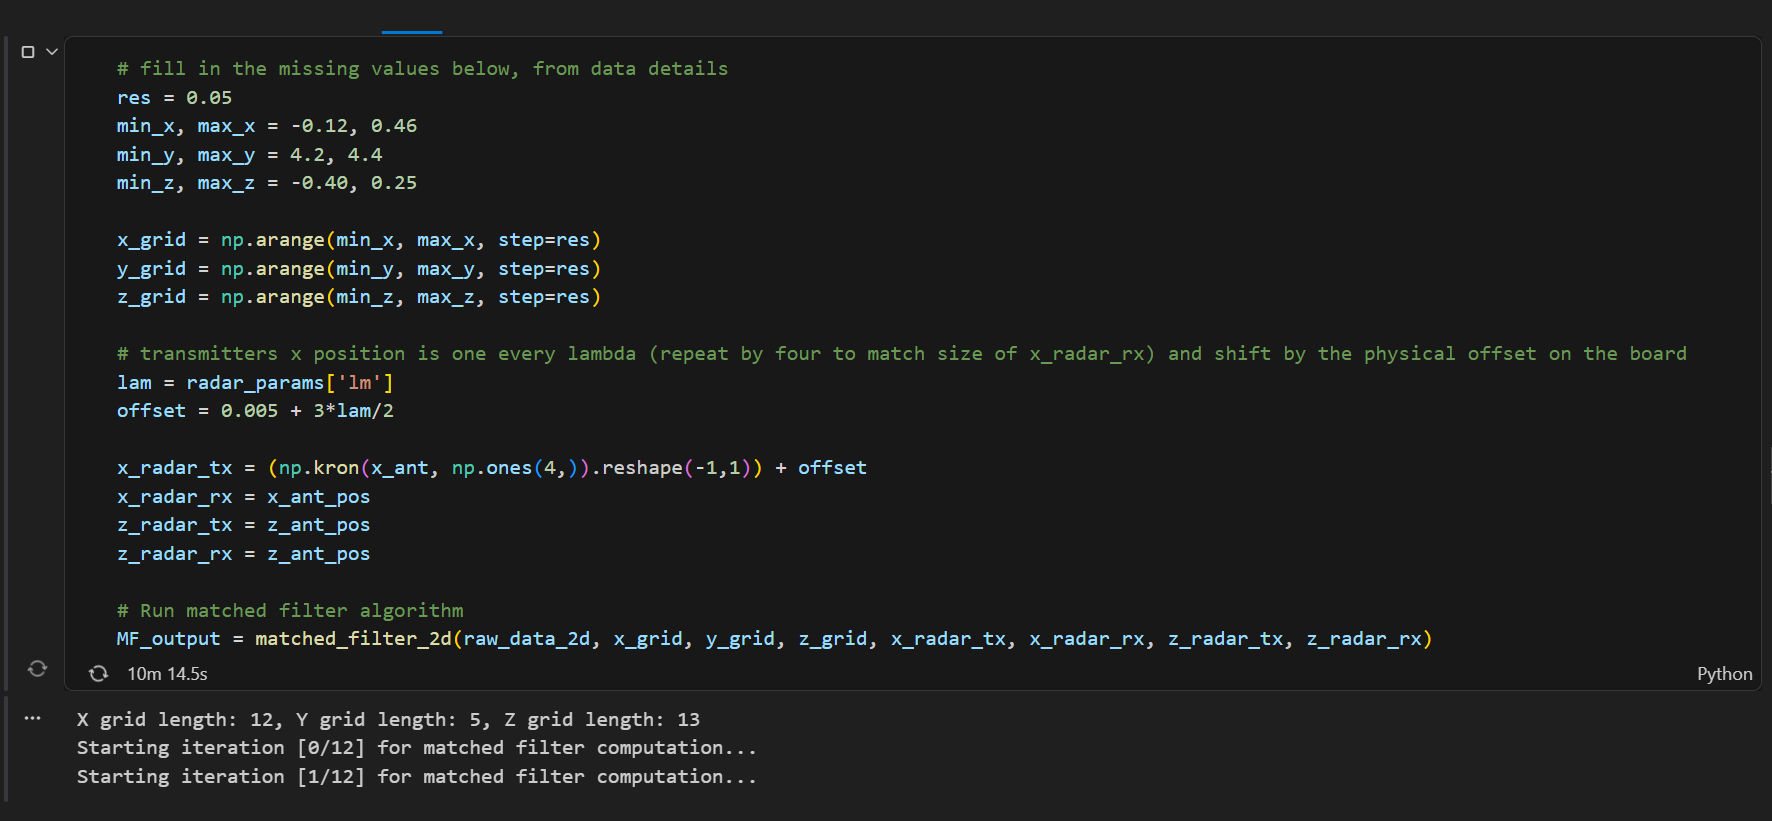